<a href="https://colab.research.google.com/github/hallewgray/Understanding-and-Enhancing-NAIRR-Utilization/blob/main/NAIRR_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os

# The library specifically wants "XDMOD_API_TOKEN" (with the word API in it)
os.environ['XDMOD_HOST'] = 'https://xdmod.access-ci.org'
os.environ['XDMOD_API_TOKEN'] = '1320.e3ec1944072deba3e2199de0c4e2456582aab329cce2305f60ec784b9ea04204'

# Now the rest of your code should run
from xdmod_data.warehouse import DataWarehouse
dw = DataWarehouse()

with dw:
    df = dw.get_raw_data(
        duration=('2024-01-01', '2024-01-07'),
        realm='SUPREMM',
        show_progress=True,
    )

Got 344320 rows...DONE


In [9]:
import sys
! {sys.executable} -m pip install --upgrade 'xdmod-data[report]>=1.0.0,<2.0.0' python-dotenv tabulate

import sys
def exception_handler(exception_type, exception, traceback):
    print("%s: %s" % (exception_type.__name__, exception), file=sys.stderr)
get_ipython()._showtraceback = exception_handler

from IPython.display import display, Markdown
def display_df_md_table(df):
    return display(Markdown(df.replace('\n', '<br/>', regex=True).to_markdown()))

import plotly.express as px
import plotly.io as pio
import xdmod_data.themes
pio.templates.default = 'timeseries'

from dotenv import load_dotenv
from os.path import expanduser
from pathlib import Path
#load_dotenv(Path(expanduser('~/xdmod-data.env'), override=True))

from xdmod_data.warehouse import DataWarehouse
dw = DataWarehouse()

with dw:
    df = dw.get_raw_data(
        duration=('2023-05-01', '2023-05-03'),
        realm='SUPREMM',
        show_progress=True,
    )

Got 145746 rows...DONE


In [12]:
print(df.columns.tolist())

['Local Job Id', 'ACCESS Credit Equivalents Charged', 'Shared', 'Cores', 'Gpu Count', 'Nodes', 'Total Cores Available', 'Cpu Time', 'Gpu Time', 'Node Time', 'Requested Nodes', 'Requested Wall Time', 'Queue', 'Wait Time', 'Wall Time', 'Eligible Time (Timestamp)', 'End Time (Timestamp)', 'Start Time (Timestamp)', 'Submit Time (Timestamp)', 'Organization', 'Resource', 'Field of Science', 'PI', 'PI ID', 'PI Institution Abbreviation', 'PI Institution ID', 'PI Institution Name', 'PI Name', 'Project Charge Number', 'Project Title', 'System Username (Deidentified)', 'Timezone', 'User', 'User ID', 'User Institution', 'User Institution Abbreviation', 'User Institution ID', 'User Institution Name', 'User Name', 'Application', 'GPU usage', 'GPU average memory usage', 'CPU Idle', 'CPU System', 'CPU User', 'FLOPS', 'CPI (ref)', 'CPI (ref) cov', 'CPLD (ref)', 'CPLD (ref) cov', 'CPU User cov', 'FLOPS cov', 'Block device "sda" data read', 'Block device "sda" data written', 'Mount point "home" data read

In [14]:
import pandas as pd
import numpy as np

# 1. Function to convert "HH:MM:SS" or "SS" to float hours
def time_to_hours(val):
    if pd.isna(val) or val == '':
        return 0.0
    try:
        # If it's already a number (seconds)
        return float(val) / 3600
    except:
        # If it's a string like '02:30:00'
        try:
            parts = str(val).split(':')
            if len(parts) == 3: # HH:MM:SS
                return int(parts[0]) + int(parts[1])/60 + int(parts[2])/3600
            elif len(parts) == 2: # MM:SS
                return int(parts[0])/60 + int(parts[1])/3600
        except:
            return 0.0

# 2. Apply mapping to your specific column names
df['wall_hrs'] = df['Wall Time'].apply(time_to_hours)
df['req_wall_hrs'] = df['Requested Wall Time'].apply(time_to_hours)
df['nodes_num'] = pd.to_numeric(df['Nodes'], errors='coerce').fillna(1)

# 3. Calculate SUs
df['su_used_calc'] = df['wall_hrs'] * df['nodes_num']
df['blocked_su'] = (df['req_wall_hrs'] - df['wall_hrs']) * df['nodes_num']
df['blocked_su'] = df['blocked_su'].clip(lower=0)

# 4. Group by Project (Charge Number)
# This handles the transition from 'Jobs' to 'Projects'
project_summary = df.groupby('Project Charge Number').agg({
    'su_used_calc': 'sum',
    'blocked_su': 'sum',
    'Local Job Id': 'count',
    'PI Name': 'first' # Keeps the PI name attached to the project
}).rename(columns={'Local Job Id': 'job_count'})

# 5. Final Waste Calculation
project_summary['project_waste_coeff'] = (
    project_summary['blocked_su'] /
    (project_summary['blocked_su'] + project_summary['su_used_calc'])
).fillna(0)

print("Project-level summary ready!")
display(project_summary.sort_values('blocked_su', ascending=False).head(10))

Project-level summary ready!


,su_used_calc,blocked_su,job_count,PI Name,project_waste_coeff
Project Charge Number,,,,,
PHY190045,22329.453333,180614.546667,12,"Blum, Thomas",0.889972
Non-ACCESS,97943.239444,165339.307222,7510,Unknown or Non-ACCESS,0.627992
CIS210079,24274.180556,139273.819444,27258,"Jung, Yong Su",0.851578
CIS210014,2104.289444,112925.895556,2985,"Watanabe, Shinji",0.981707
MCB130189,2272.6425,87519.410556,2379,"Ecker, Joseph",0.97469
PHY150040,13617.9675,80774.432778,3933,"Halzen, Francis",0.85573
CIS230021,4805.715833,66427.0075,17929,"Kihara, Daisuke",0.932535
MCA93S002,2287.790833,63232.515833,2588,"Gottlieb, Steven",0.965083
PHY170050,1941.044444,40226.964444,725,"Bose, Tulika",0.953969


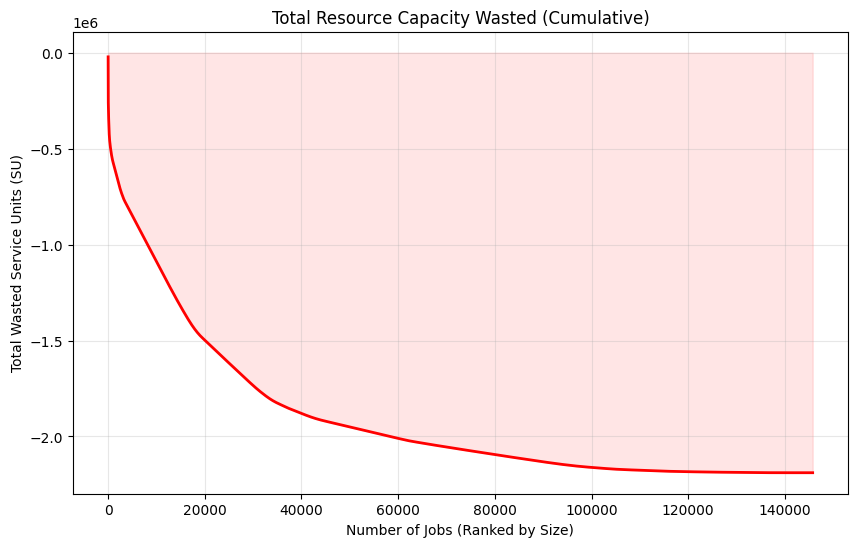

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Sort jobs by their individual waste (Blocked SUs)
df_sorted = df.sort_values('blocked_su', ascending=False).reset_index()
df_sorted['cumulative_waste'] = df_sorted['blocked_su'].cumsum()

plt.figure(figsize=(10, 6))
plt.fill_between(df_sorted.index, -df_sorted['cumulative_waste'], color='red', alpha=0.1)
plt.plot(df_sorted.index, -df_sorted['cumulative_waste'], color='red', lw=2)

plt.title('Total Resource Capacity Wasted (Cumulative)')
plt.xlabel('Number of Jobs (Ranked by Size)')
plt.ylabel('Total Wasted Service Units (SU)')
plt.grid(True, alpha=0.3)
plt.show()

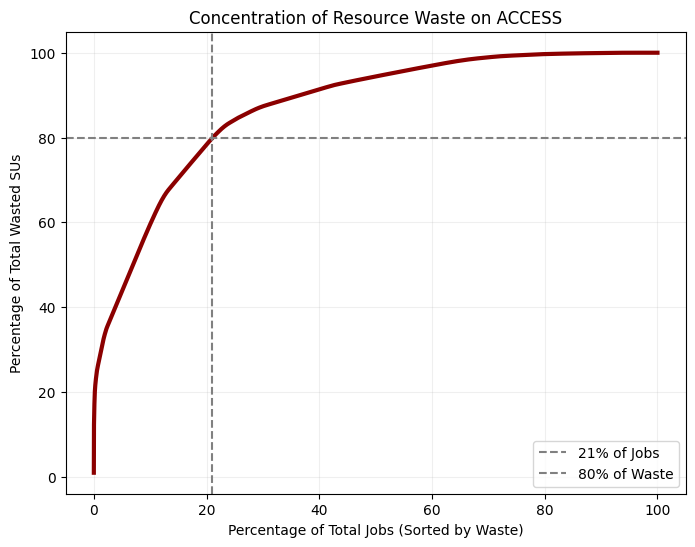

In [16]:
# Calculate percentage of total jobs and percentage of total waste
df_sorted['pct_jobs'] = (df_sorted.index / len(df_sorted)) * 100
df_sorted['pct_waste'] = (df_sorted['cumulative_waste'] / df_sorted['blocked_su'].sum()) * 100

plt.figure(figsize=(8, 6))
plt.plot(df_sorted['pct_jobs'], df_sorted['pct_waste'], color='darkred', lw=3)

# Add the 21/80 reference lines
plt.axvline(21, color='gray', linestyle='--', label='21% of Jobs')
plt.axhline(80, color='gray', linestyle='--', label='80% of Waste')

plt.title('Concentration of Resource Waste on ACCESS')
plt.xlabel('Percentage of Total Jobs (Sorted by Waste)')
plt.ylabel('Percentage of Total Wasted SUs')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

--- Project Allocation Waste Audit ---
                       Total_Used_SUs  Total_Blocked_SUs  Project_Efficiency
Project Charge Number                                                       
PHY190045                22329.453333      180614.546667            0.110028
Non-ACCESS               97943.239444      165339.307222            0.372008
CIS210079                24274.180556      139273.819444            0.148422
CIS210014                 2104.289444      112925.895556            0.018293
MCB130189                   2272.6425       87519.410556             0.02531
PHY150040                  13617.9675       80774.432778             0.14427
CIS230021                 4805.715833         66427.0075            0.067465
MCA93S002                 2287.790833       63232.515833            0.034917
PHY170050                 1941.044444       40226.964444            0.046031
CIS230045                   52.836944       37956.163056             0.00139


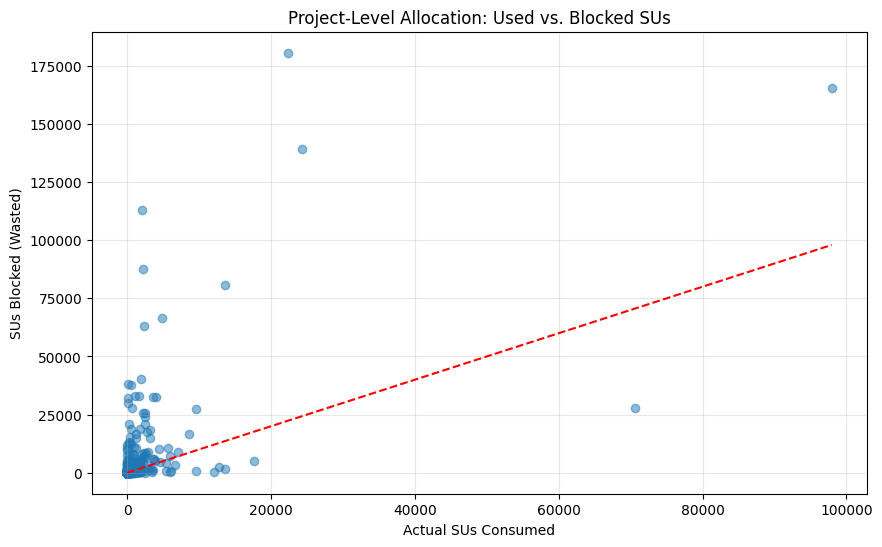

In [17]:
# 2. Now aggregate by 'Project Charge Number' (or PI / Organization)
project_summary = df.groupby('Project Charge Number').agg({
    'su_used_calc': 'sum',
    'blocked_su': 'sum',
    'Submit Time (Timestamp)': ['min', 'max'],
    'Local Job Id': 'count'
})

# Flatten the multi-index columns created by .agg
project_summary.columns = ['Total_Used_SUs', 'Total_Blocked_SUs', 'First_Submit', 'Last_Submit', 'Job_Count']

# 3. Calculate Project-Level Efficiency (The 'E' from your formula)
project_summary['Project_Efficiency'] = (
    project_summary['Total_Used_SUs'] /
    (project_summary['Total_Used_SUs'] + project_summary['Total_Blocked_SUs'] + 0.001)
)

# 4. Filter for Zhenhua's "Overestimators"
# Projects that blocked more than they used
top_project_wasters = project_summary.sort_values('Total_Blocked_SUs', ascending=False)

print("--- Project Allocation Waste Audit ---")
print(top_project_wasters[['Total_Used_SUs', 'Total_Blocked_SUs', 'Project_Efficiency']].head(10))

# 5. Visualize the "Project Waste Distribution"
plt.figure(figsize=(10,6))
plt.scatter(project_summary['Total_Used_SUs'], project_summary['Total_Blocked_SUs'], alpha=0.5)
plt.plot([0, project_summary['Total_Used_SUs'].max()], [0, project_summary['Total_Used_SUs'].max()], 'r--')
plt.title('Project-Level Allocation: Used vs. Blocked SUs')
plt.xlabel('Actual SUs Consumed')
plt.ylabel('SUs Blocked (Wasted)')
plt.grid(True, alpha=0.3)
plt.show()

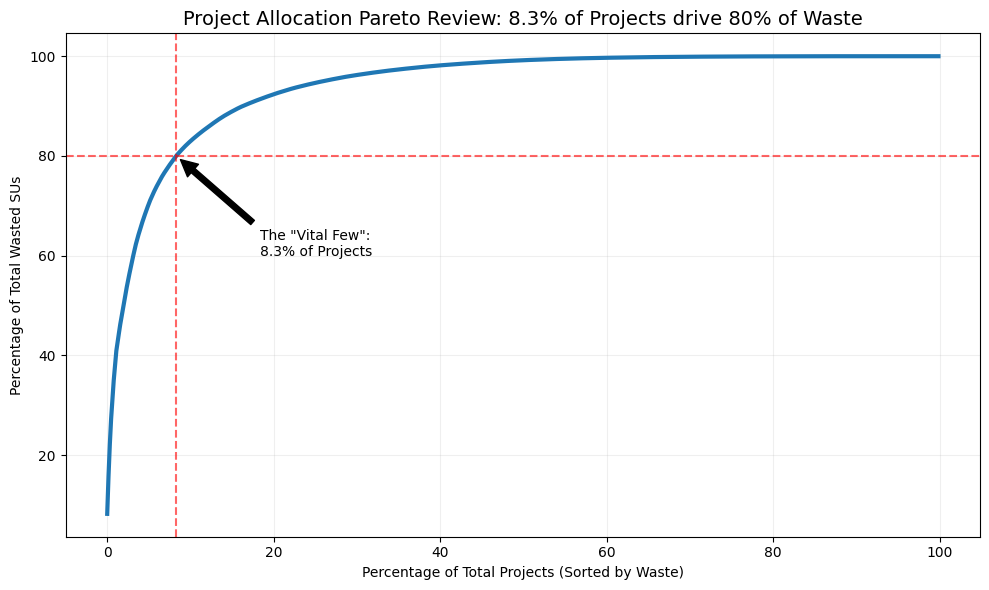

Result: 8.29% of projects are responsible for 80% of the system waste.


In [18]:
# 1. Prepare Project Data (using the summary we built)
# We sort projects by the amount of waste (Total_Blocked_SUs) they generated
pareto_df = project_summary.sort_values('Total_Blocked_SUs', ascending=False).reset_index()

# 2. Calculate Cumulative Percentages
pareto_df['cum_waste'] = pareto_df['Total_Blocked_SUs'].cumsum()
pareto_df['pct_waste'] = (pareto_df['cum_waste'] / pareto_df['Total_Blocked_SUs'].sum()) * 100
pareto_df['pct_projects'] = (pareto_df.index / len(pareto_df)) * 100

# 3. Find the "Pareto Point" (Where Waste hits 80%)
pareto_point = pareto_df[pareto_df['pct_waste'] >= 80].iloc[0]
project_threshold = pareto_point['pct_projects']

# --- THE VISUALIZATION ---
plt.figure(figsize=(10, 6))

# Plot the Curve
plt.plot(pareto_df['pct_projects'], pareto_df['pct_waste'], color='#1f77b4', lw=3, label='Cumulative Waste %')

# Add the 80/X Intersect Lines
plt.axhline(80, color='red', linestyle='--', alpha=0.6)
plt.axvline(project_threshold, color='red', linestyle='--', alpha=0.6)

# Formatting to match the "Professional" look of your Power BI dashboard
plt.title(f'Project Allocation Pareto Review: {project_threshold:.1f}% of Projects drive 80% of Waste', fontsize=14)
plt.xlabel('Percentage of Total Projects (Sorted by Waste)')
plt.ylabel('Percentage of Total Wasted SUs')
plt.annotate(f'The "Vital Few":\n{project_threshold:.1f}% of Projects',
             xy=(project_threshold, 80), xytext=(project_threshold+10, 60),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Result: {project_threshold:.2f}% of projects are responsible for 80% of the system waste.")

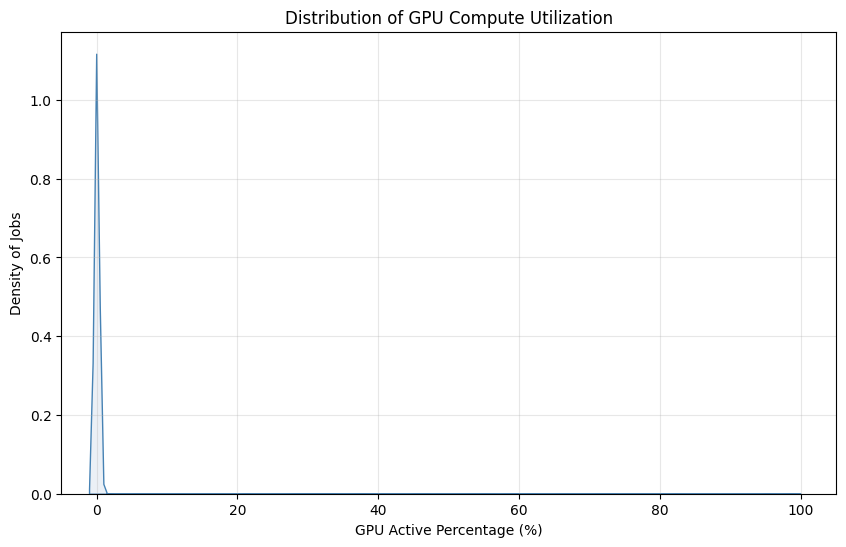

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 6))
# Ensure GPU usage is numeric
gpu_data = pd.to_numeric(df['GPU usage'], errors='coerce').fillna(0)

sns.kdeplot(gpu_data, fill=True, color='lightsteelblue', edgecolor='steelblue')
plt.title('Distribution of GPU Compute Utilization')
plt.xlabel('GPU Active Percentage (%)')
plt.ylabel('Density of Jobs')
plt.xlim(-5, 105) # Focus on 0-100% range
plt.grid(True, alpha=0.3)
plt.show()

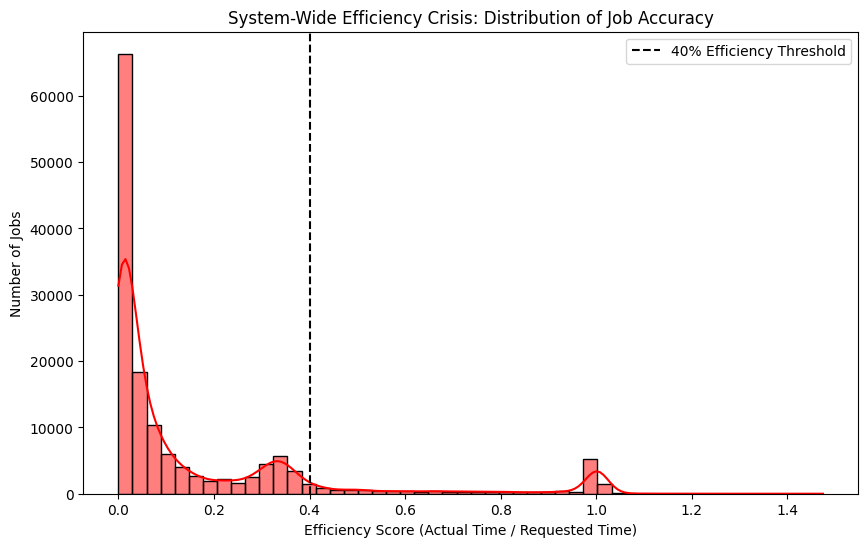

In [20]:
# Efficiency Score = Actual / (Actual + Blocked)
df['efficiency_score'] = df['wall_hrs'] / (df['req_wall_hrs'] + 0.0001)

plt.figure(figsize=(10, 6))
sns.histplot(df['efficiency_score'], bins=50, kde=True, color='red', alpha=0.5)

# Add the 40% Threshold line
plt.axvline(0.4, color='black', linestyle='--', label='40% Efficiency Threshold')

plt.title('System-Wide Efficiency Crisis: Distribution of Job Accuracy')
plt.xlabel('Efficiency Score (Actual Time / Requested Time)')
plt.ylabel('Number of Jobs')
plt.legend()
plt.show()